In [1]:
import yfinance as yf

In [2]:
sp500 = yf.Ticker("^GSPC")

In [3]:
sp500 = sp500.history(period = "max")

<Axes: xlabel='Date'>

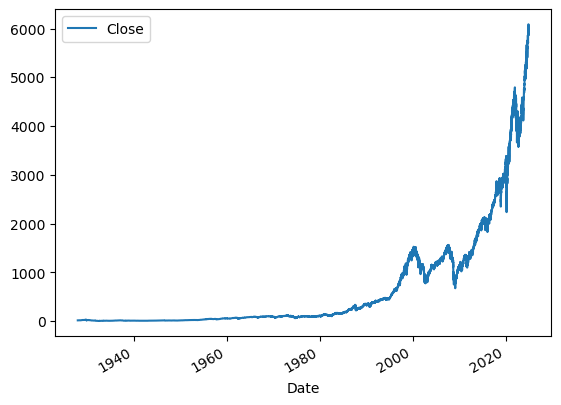

In [4]:
sp500.plot.line(y="Close", use_index = True)

In [5]:
del sp500["Dividends"]
del sp500["Stock Splits"]

In [6]:
sp500["Tomorrow"] = sp500["Close"].shift(-1)

In [7]:
sp500

,Open,High,Low,Close,Volume,Tomorrow
Date,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000
...,...,...,...,...,...,...
2024-12-17 00:00:00-05:00,6052.549805,6057.680176,6035.189941,6050.609863,4544500000,5872.160156
2024-12-18 00:00:00-05:00,6047.649902,6070.669922,5867.790039,5872.160156,5246960000,5867.080078
2024-12-19 00:00:00-05:00,5912.709961,5935.520020,5866.069824,5867.080078,4896880000,5930.850098


In [8]:
sp500["Target"] = (sp500["Tomorrow"] >sp500["Close"]).astype(int)

In [9]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000,1
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999,0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999,0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000,1
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000,0
...,...,...,...,...,...,...,...
2024-12-17 00:00:00-05:00,6052.549805,6057.680176,6035.189941,6050.609863,4544500000,5872.160156,0
2024-12-18 00:00:00-05:00,6047.649902,6070.669922,5867.790039,5872.160156,5246960000,5867.080078,0
2024-12-19 00:00:00-05:00,5912.709961,5935.520020,5866.069824,5867.080078,4896880000,5930.850098,1


In [7]:
sp500 = sp500.loc["1990-01-01":].copy()
sp500

,Open,High,Low,Close,Volume,Tomorrow
Date,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000
...,...,...,...,...,...,...
2023-03-27 00:00:00-04:00,3982.929932,4003.830078,3970.489990,3977.530029,4233540000,3971.270020
2023-03-28 00:00:00-04:00,3974.129883,3979.199951,3951.530029,3971.270020,4014600000,4027.810059
2023-03-29 00:00:00-04:00,3999.530029,4030.590088,3999.530029,4027.810059,4145250000,4050.830078


In [8]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators = 100, min_samples_split = 100, random_state = 1)

train = sp500.iloc[:-100]
test = sp500.iloc[-100:]

predictors = ["Close", "Volume", "Open", "High", "Low"]
model.fit(train[predictors], train["Target"])

In [9]:
from sklearn.metrics import precision_score

preds = model.predict(test[predictors])

import pandas as pd

preds = pd.Series(preds, index = test.index)

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000,1
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999,0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999,0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000,1
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000,0
...,...,...,...,...,...,...,...
2023-03-27 00:00:00-04:00,3982.929932,4003.830078,3970.489990,3977.530029,4233540000,3971.270020,0
2023-03-28 00:00:00-04:00,3974.129883,3979.199951,3951.530029,3971.270020,4014600000,4027.810059,1
2023-03-29 00:00:00-04:00,3999.530029,4030.590088,3999.530029,4027.810059,4145250000,4050.830078,1


In [10]:
precision_score(test["Target"], preds)

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1990-01-02 00:00:00-05:00,353.399994,359.690002,351.980011,359.690002,162070000,358.760010,0
1990-01-03 00:00:00-05:00,359.690002,360.589996,357.890015,358.760010,192330000,355.670013,0
1990-01-04 00:00:00-05:00,358.760010,358.760010,352.890015,355.670013,177000000,352.200012,0
1990-01-05 00:00:00-05:00,355.670013,355.670013,351.350006,352.200012,158530000,353.790009,1
1990-01-08 00:00:00-05:00,352.200012,354.239990,350.540009,353.790009,140110000,349.619995,0
...,...,...,...,...,...,...,...
2023-03-27 00:00:00-04:00,3982.929932,4003.830078,3970.489990,3977.530029,4233540000,3971.270020,0
2023-03-28 00:00:00-04:00,3974.129883,3979.199951,3951.530029,3971.270020,4014600000,4027.810059,1
2023-03-29 00:00:00-04:00,3999.530029,4030.590088,3999.530029,4027.810059,4145250000,4050.830078,1


RandomForestClassifier(min_samples_split=100, random_state=1)

0.375

<Axes: xlabel='Date'>

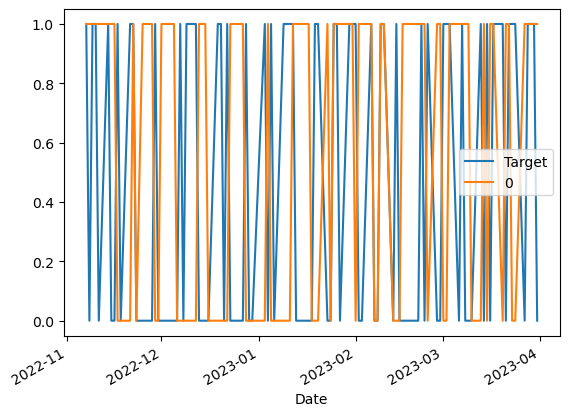

In [14]:
combined = pd.concat([test["Target"], preds], axis = 1)
combined.plot()
#orange is prediction
#blue is what actually happened

In [15]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train["Target"])
    preds = model.predict(test[predictors])
    preds = pd.Series(preds, index = test.index, name = "Predictions")
    combined = pd.concat([test["Target"], preds], axis = 1)
    return combined

In [35]:
def backtest(data, model, predictors, start = 2500, step = 250):
    all_predictions = []
    
    for i in range(start, data.shape[0], step):
        train = data.iloc[0:i].copy()
        test = data.iloc[i:(i+step)].copy()
        predictions = predict(train,test, predictors, model)
        all_predictions.append(predictions)
    return pd.concat(all_predictions)
        

In [17]:
predictions = backtest(sp500, model, predictors)

In [18]:
predictions["Predictions"].value_counts()

0    3408
1    2469
Name: Predictions, dtype: int64

In [19]:
precision_score(predictions["Target"], predictions["Predictions"])

0.5277440259214257

In [20]:
predictions["Target"].value_counts() / predictions.shape[0]

1    0.533946
0    0.466054
Name: Target, dtype: float64

In [21]:
horizons = [2,5,60,250,1000]
#horizons are how we look at rolling means
#2 - last trading days
#5 - last trading week
#60 - last trading month
#250 - last trading year
#1000 - last trading 

new_predictors = [] 

for horizon in horizons:
    rolling_averages = sp500.rolling(horizon).mean()
    
    ratio_column = f"Close_Ratio_{horizon}"
    sp500[ratio_column] = sp500["Close"] / rolling_averages["Close"]
    
    trend_column = f"Trend_{horizon}"
    sp500[trend_column] = sp500.shift(1).rolling(horizon).sum()["Target"]
    
    new_predictors += [ratio_column, trend_column]

In [22]:
sp500 = sp500.dropna()
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,Trend_5,Close_Ratio_60,Trend_60,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,
1993-12-14 00:00:00-05:00,465.730011,466.119995,462.459991,463.059998,275050000,461.839996,0,0.997157,1.0,0.996617,1.0,1.000283,32.0,1.028047,127.0,1.176082,512.0
1993-12-15 00:00:00-05:00,463.059998,463.690002,461.839996,461.839996,331770000,463.339996,1,0.998681,0.0,0.995899,1.0,0.997329,32.0,1.025151,126.0,1.172676,512.0
1993-12-16 00:00:00-05:00,461.859985,463.980011,461.859985,463.339996,284620000,466.380005,1,1.001621,1.0,0.999495,2.0,1.000311,32.0,1.028274,127.0,1.176163,513.0
1993-12-17 00:00:00-05:00,463.339996,466.380005,463.339996,466.380005,363750000,465.850006,0,1.003270,2.0,1.004991,3.0,1.006561,32.0,1.034781,128.0,1.183537,514.0
1993-12-20 00:00:00-05:00,466.380005,466.899994,465.529999,465.850006,255900000,465.299988,0,0.999431,1.0,1.003784,2.0,1.005120,32.0,1.033359,128.0,1.181856,513.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-24 00:00:00-04:00,3939.209961,3972.739990,3909.159912,3970.989990,4583970000,3977.530029,1,1.002812,2.0,1.002212,4.0,0.995488,30.0,0.994562,112.0,1.071994,534.0
2023-03-27 00:00:00-04:00,3982.929932,4003.830078,3970.489990,3977.530029,4233540000,3971.270020,0,1.000823,2.0,1.002549,4.0,0.996319,31.0,0.996797,112.0,1.073445,534.0
2023-03-28 00:00:00-04:00,3974.129883,3979.199951,3951.530029,3971.270020,4014600000,4027.810059,1,0.999212,1.0,1.002568,3.0,0.994244,30.0,0.995888,111.0,1.071445,533.0


In [23]:
model = RandomForestClassifier(n_estimators = 200, min_samples_split = 50, random_state = 1)

In [24]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train["Target"])
    preds = model.predict_proba(test[predictors])[:,1]#returns probability that a row is a 0 or 1 default threshold is .5
    preds[preds >= .6] = 1
    preds[preds < .6] = 0
    preds = pd.Series(preds, index = test.index, name = "Predictions")
    combined = pd.concat([test["Target"], preds], axis = 1)
    return combined

In [25]:
predictions = backtest(sp500, model, new_predictors)

In [26]:
predictions["Predictions"].value_counts()

0.0    4063
1.0     813
Name: Predictions, dtype: int64

In [27]:
precision_score(predictions["Target"], predictions["Predictions"])

0.5694956949569495

In [28]:
#apikey: deee9e25196e8adae1bb08246163f630

from fredapi import Fred
fred = Fred(api_key = "deee9e25196e8adae1bb08246163f630")

In [29]:



intdata = pd.Series(fred.get_series("OBMMIC15YF"))

In [30]:
sp500 = sp500.loc["2017-01-03":].copy()
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,Trend_5,Close_Ratio_60,Trend_60,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,
2017-01-03 00:00:00-05:00,2251.570068,2263.879883,2245.129883,2257.830078,3773010000,2270.750000,1,1.004225,1.0,1.002169,2.0,1.031970,30.0,1.077023,131.0,1.165476,538.0
2017-01-04 00:00:00-05:00,2261.600098,2272.820068,2261.600098,2270.750000,3768890000,2269.000000,0,1.002853,2.0,1.007736,2.0,1.036951,31.0,1.082510,132.0,1.171662,538.0
2017-01-05 00:00:00-05:00,2268.179932,2271.500000,2260.449951,2269.000000,3785080000,2276.979980,1,0.999615,1.0,1.005257,2.0,1.035322,30.0,1.080960,132.0,1.170278,537.0
2017-01-06 00:00:00-05:00,2271.139893,2282.100098,2264.060059,2276.979980,3342080000,2268.899902,0,1.001755,1.0,1.006321,3.0,1.037856,31.0,1.084032,132.0,1.173912,537.0
2017-01-09 00:00:00-05:00,2273.590088,2275.489990,2268.899902,2268.899902,3219730000,2268.899902,0,0.998223,1.0,1.000092,3.0,1.033155,30.0,1.079506,131.0,1.169275,536.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-24 00:00:00-04:00,3939.209961,3972.739990,3909.159912,3970.989990,4583970000,3977.530029,1,1.002812,2.0,1.002212,4.0,0.995488,30.0,0.994562,112.0,1.071994,534.0
2023-03-27 00:00:00-04:00,3982.929932,4003.830078,3970.489990,3977.530029,4233540000,3971.270020,0,1.000823,2.0,1.002549,4.0,0.996319,31.0,0.996797,112.0,1.073445,534.0
2023-03-28 00:00:00-04:00,3974.129883,3979.199951,3951.530029,3971.270020,4014600000,4027.810059,1,0.999212,1.0,1.002568,3.0,0.994244,30.0,0.995888,111.0,1.071445,533.0


In [31]:
ra = []
for x in range(sp500.shape[0]):
    ra.append(intdata.loc[str(sp500.index.values[x])[:10]])

sp500["intRates"] = ra

In [32]:
new_predictors.append("intRates")
new_predictors

['Close_Ratio_2',
 'Trend_2',
 'Close_Ratio_5',
 'Trend_5',
 'Close_Ratio_60',
 'Trend_60',
 'Close_Ratio_250',
 'Trend_250',
 'Close_Ratio_1000',
 'Trend_1000',
 'intRates']

In [33]:
model = RandomForestClassifier(n_estimators = 200, min_samples_split = 50, random_state = 1)

In [37]:
predictions = backtest(sp500, model, new_predictors)
print(predictions["Predictions"].value_counts())
precision_score(predictions["Target"], predictions["Predictions"])

ValueError: No objects to concatenate